# Financial Market Early Warning System

## Detecting Stress Through Cross-Sector Dependence

This project will investigate whether changes in dependence across major US equity sectors can provide useful early-warning signals of broad market stress.

The analysis will use nine long-history Select Sector SPDR ETFs to measure changes in market structure, while SPY will be used as the broad-market benchmark.

**Study period:** January 2005 – July 2026  
**Data frequency:** Daily  
**Primary rolling window:** 60 trading days  
**Primary warning horizon:** 20 trading days

## 1. Setup and Data Collection

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

In [2]:
all_tickers = ["SPY","XLB", "XLE", "XLF", "XLI", "XLK", "XLP", "XLU", "XLV", "XLY"]

In [3]:
data = yf.download(all_tickers, start="2005-01-01", end="2026-08-01", auto_adjust=True, progress=False)

prices = data["Close"].copy()

In [4]:
prices.head()

Ticker,SPY,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
Date,,,,,,,,,,
2005-01-03,81.174622,9.217490,9.504982,16.086000,20.512524,8.010024,13.196808,6.583833,20.733532,13.457801
2005-01-04,80.182663,9.051497,9.456072,15.932645,20.259447,7.860768,13.151071,6.538393,20.566778,13.300428
2005-01-05,79.629372,8.926212,9.415309,15.906204,20.119589,7.833982,13.082454,6.435558,20.532024,13.250530
2005-01-06,80.034233,8.985724,9.578347,15.985526,20.186184,7.811015,13.145350,6.469037,20.684902,13.181430
2005-01-07,79.919540,9.001380,9.502265,15.900917,20.092947,7.826325,13.208251,6.469037,20.671003,13.177594


In [5]:
prices.tail()

Ticker,SPY,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
Date,,,,,,,,,,
2026-07-27,739.090027,51.389999,58.360001,56.880001,183.199997,174.300003,85.360001,45.680000,163.399994,110.839996
2026-07-28,740.859985,52.340000,57.570000,57.599998,182.490005,171.089996,87.059998,45.520000,167.259995,112.480003
2026-07-29,729.460022,51.740002,58.650002,56.680000,176.660004,166.570007,87.360001,44.910000,166.240005,111.610001
2026-07-30,741.690002,51.639999,58.959999,57.000000,178.389999,175.729996,85.470001,44.660000,163.520004,112.389999
2026-07-31,747.030029,50.430000,59.549999,56.939999,179.839996,175.350006,85.050003,44.349998,162.550003,116.089996


In [6]:
prices.shape

(5428, 10)

In [7]:
prices.index.min()

Timestamp('2005-01-03 00:00:00')

In [8]:
prices.index.max()

Timestamp('2026-07-31 00:00:00')

In [9]:
prices.isna().sum()

Ticker
SPY    0
XLB    0
XLE    0
XLF    0
XLI    0
XLK    0
XLP    0
XLU    0
XLV    0
XLY    0
dtype: int64

In [10]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5428 entries, 2005-01-03 to 2026-07-31
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SPY     5428 non-null   float64
 1   XLB     5428 non-null   float64
 2   XLE     5428 non-null   float64
 3   XLF     5428 non-null   float64
 4   XLI     5428 non-null   float64
 5   XLK     5428 non-null   float64
 6   XLP     5428 non-null   float64
 7   XLU     5428 non-null   float64
 8   XLV     5428 non-null   float64
 9   XLY     5428 non-null   float64
dtypes: float64(10)
memory usage: 466.5 KB


In [11]:
prices.to_csv("sector_etf_prices.csv")

## 2. Data Preparation and Return Construction

Daily adjusted prices will be converted into log returns for the subsequent analysis. Basic validation checks will be performed to ensure that the return series are complete and suitable for the rolling market-structure analysis.

In [12]:
log_returns = np.log(prices / prices.shift(1))

log_returns.head()

Ticker,SPY,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
Date,,,,,,,,,,
2005-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-04,-0.012295,-0.018173,-0.005159,-0.009579,-0.012414,-0.018809,-0.003472,-0.006926,-0.008075,-0.011763
2005-01-05,-0.006924,-0.013938,-0.004320,-0.001661,-0.006927,-0.003413,-0.005231,-0.015853,-0.001691,-0.003759
2005-01-06,0.005071,0.006645,0.017168,0.004974,0.003304,-0.002936,0.004796,0.005189,0.007418,-0.005229
2005-01-07,-0.001434,0.001741,-0.007975,-0.005307,-0.004630,0.001958,0.004774,0.000000,-0.000672,-0.000291


In [13]:
log_returns = log_returns.dropna()

log_returns.head()

Ticker,SPY,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
Date,,,,,,,,,,
2005-01-04,-0.012295,-0.018173,-0.005159,-0.009579,-0.012414,-0.018809,-0.003472,-0.006926,-0.008075,-0.011763
2005-01-05,-0.006924,-0.013938,-0.004320,-0.001661,-0.006927,-0.003413,-0.005231,-0.015853,-0.001691,-0.003759
2005-01-06,0.005071,0.006645,0.017168,0.004974,0.003304,-0.002936,0.004796,0.005189,0.007418,-0.005229
2005-01-07,-0.001434,0.001741,-0.007975,-0.005307,-0.004630,0.001958,0.004774,0.000000,-0.000672,-0.000291
2005-01-10,0.004717,0.004513,0.007408,0.000997,0.003639,0.000000,0.006042,0.005162,0.008702,0.003779


In [14]:
log_returns.shape

(5427, 10)

In [15]:
log_returns.index.min()

Timestamp('2005-01-04 00:00:00')

In [16]:
log_returns.index.max()

Timestamp('2026-07-31 00:00:00')

In [17]:
log_returns.isna().sum()

Ticker
SPY    0
XLB    0
XLE    0
XLF    0
XLI    0
XLK    0
XLP    0
XLU    0
XLV    0
XLY    0
dtype: int64

In [18]:
log_returns.describe().T

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
SPY,5427.0,0.000409,0.011935,-0.115887,-0.003949,0.000718,0.005792,0.135577
XLB,5427.0,0.000313,0.014636,-0.132527,-0.006588,0.000864,0.008012,0.131534
XLE,5427.0,0.000338,0.018833,-0.224910,-0.008175,0.000887,0.009882,0.152503
XLF,5427.0,0.000233,0.018208,-0.182321,-0.006263,0.000669,0.007394,0.152394
XLI,5427.0,0.000400,0.013131,-0.120408,-0.005352,0.000891,0.006788,0.119127
XLK,5427.0,0.000569,0.014245,-0.148662,-0.005541,0.001146,0.007381,0.130136
XLP,5427.0,0.000343,0.008919,-0.098668,-0.003966,0.000659,0.005072,0.081678
XLU,5427.0,0.000351,0.011719,-0.120561,-0.005232,0.000994,0.006512,0.120388
XLV,5427.0,0.000379,0.010507,-0.103818,-0.004541,0.000603,0.005885,0.113817


In [19]:
np.isinf(log_returns).sum()

Ticker
SPY    0
XLB    0
XLE    0
XLF    0
XLI    0
XLK    0
XLP    0
XLU    0
XLV    0
XLY    0
dtype: int64

In [20]:
sector_tickers = ["XLB", "XLE", "XLF", "XLI", "XLK","XLP", "XLU", "XLV", "XLY"]

sector_returns = log_returns[sector_tickers].copy()
spy_returns = log_returns["SPY"].copy()

print("Sector returns shape:", sector_returns.shape)
print("SPY returns shape:", spy_returns.shape)

Sector returns shape: (5427, 9)
SPY returns shape: (5427,)


In [21]:
log_returns.to_csv("log_returns.csv")

## 3. Exploratory Market Behaviour

This section will explore broad-market and sector-level behaviour over the study period. SPY will be used as the market benchmark to examine cumulative performance, drawdowns and rolling volatility, while sector ETFs will be used to compare performance across different areas of the market.

In [22]:
spy_cumulative = np.exp(spy_returns.cumsum())

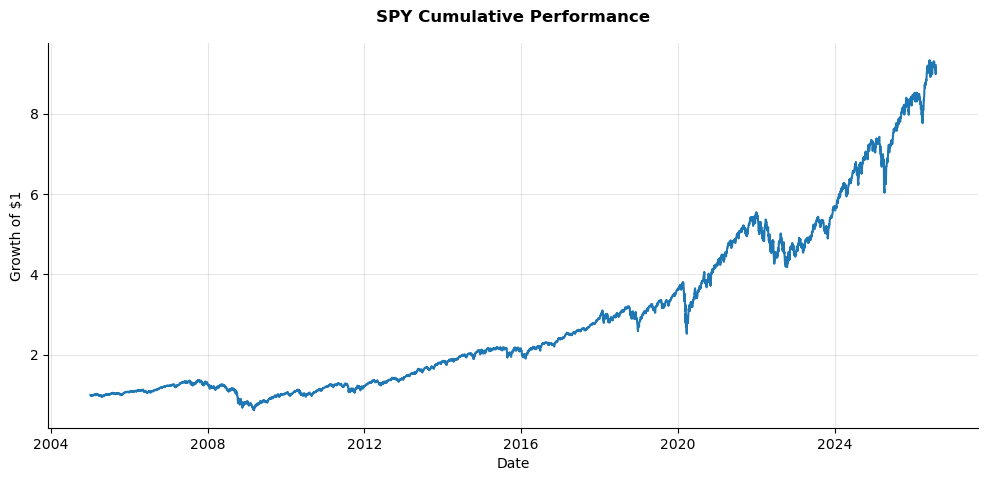

In [23]:
plt.figure(figsize=(12, 5))

plt.plot(spy_cumulative.index, spy_cumulative)

plt.title("SPY Cumulative Performance", fontsize=12, fontweight="bold", pad=15)
plt.xlabel("Date")
plt.ylabel("Growth of $1")

plt.gca().spines[["top", "right"]].set_visible(False)
plt.grid(alpha=0.3)

plt.show()

In [24]:
running_peak = spy_cumulative.cummax()

spy_drawdown = (spy_cumulative / running_peak) - 1

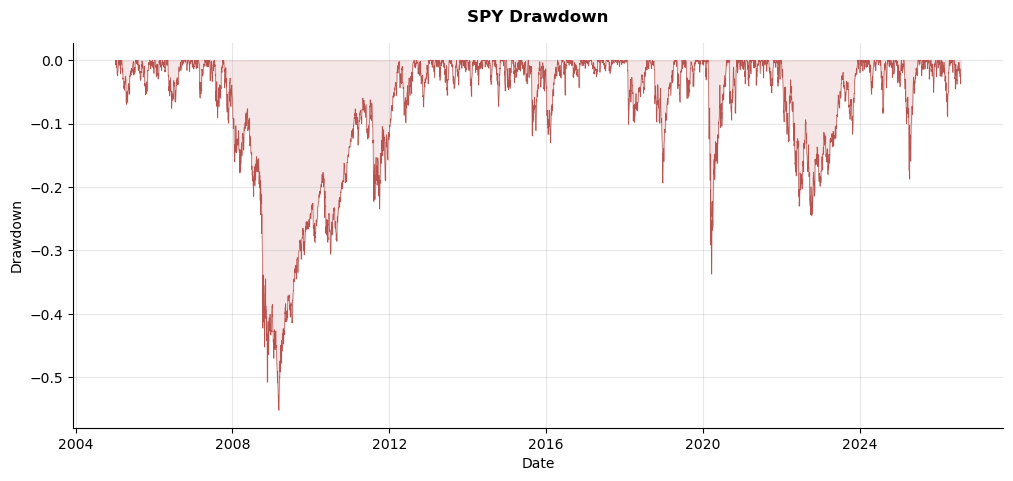

In [25]:
plt.figure(figsize=(12, 5))

plt.plot(spy_drawdown.index, spy_drawdown, color="#B85450", linewidth=0.5)
plt.fill_between(spy_drawdown.index, spy_drawdown, 0, color="#D9A3A0", alpha=0.25)

plt.title("SPY Drawdown", fontsize=12, fontweight="bold", pad=15)
plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.gca().spines[["top", "right"]].set_visible(False)
plt.grid(alpha=0.3)

plt.show()

In [26]:
max_drawdown = spy_drawdown.min()
max_drawdown_date = spy_drawdown.idxmin()

print(f"Maximum Drawdown: {max_drawdown:.2%}")
print(f"Maximum Drawdown Date: {max_drawdown_date.date()}")

Maximum Drawdown: -55.19%
Maximum Drawdown Date: 2009-03-09


In [27]:
rolling_window = 60

spy_rolling_vol = (spy_returns.rolling(rolling_window).std() * np.sqrt(252))

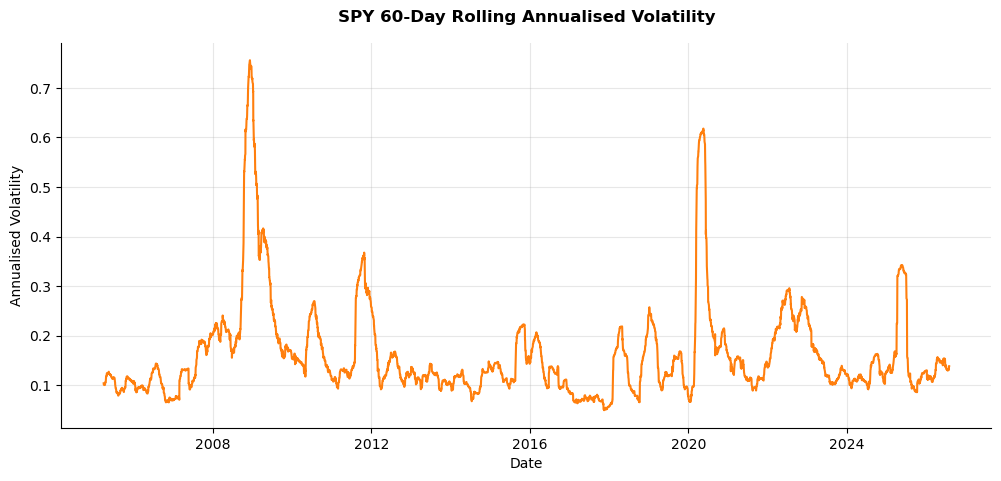

In [28]:
plt.figure(figsize=(12, 5))

plt.plot(spy_rolling_vol.index, spy_rolling_vol, color="tab:orange")

plt.title("SPY 60-Day Rolling Annualised Volatility", fontsize=12, fontweight="bold", pad=15)
plt.xlabel("Date")
plt.ylabel("Annualised Volatility")

plt.gca().spines[["top", "right"]].set_visible(False)
plt.grid(alpha=0.3)

plt.show()

In [29]:
spy_rolling_vol.nlargest(10)

Date
2008-12-08    0.755843
2008-12-05    0.751626
2008-12-09    0.750812
2008-12-10    0.749886
2008-12-04    0.749045
2008-12-03    0.748449
2008-12-02    0.747556
2008-12-11    0.746131
2008-12-16    0.744823
2008-12-18    0.744330
Name: SPY, dtype: float64

In [30]:
sector_cumulative = np.exp(sector_returns.cumsum())

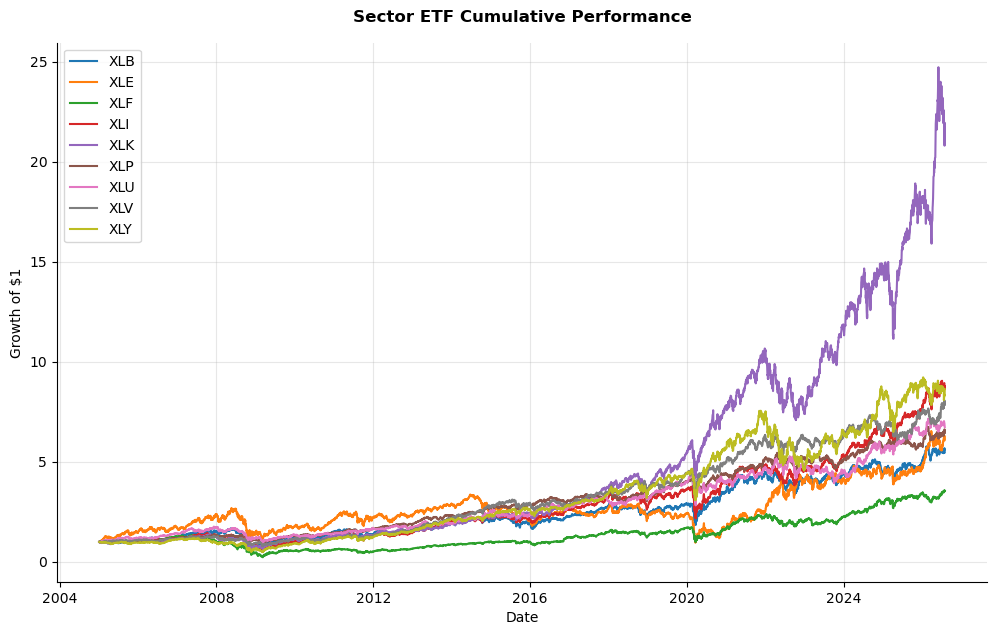

In [31]:
plt.figure(figsize=(12, 7))

for ticker in sector_cumulative.columns:
    plt.plot(
        sector_cumulative.index,
        sector_cumulative[ticker],
        label=ticker
    )

plt.title("Sector ETF Cumulative Performance", fontsize=12, fontweight="bold", pad=15)
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()

plt.gca().spines[["top", "right"]].set_visible(False)
plt.grid(alpha=0.3)

plt.show()

## 4. Dynamic Cross-Sector Dependence

This section will examine how dependence across the nine US equity sectors changes over time. A 60-day rolling correlation matrix will be estimated using sector returns, and the average pairwise correlation will be used as a summary measure of market-wide sector co-movement. The relationship between cross-sector dependence and SPY volatility will then be examined.

In [32]:
rolling_window = 60
avg_pairwise_corr = pd.Series(index=sector_returns.index, dtype=float, name="Average Pairwise Correlation")

for i in range(rolling_window - 1, len(sector_returns)):
    window_returns = sector_returns.iloc[i - rolling_window + 1 : i + 1]
    corr_matrix = window_returns.corr()
    upper_triangle = corr_matrix.values[np.triu_indices_from(corr_matrix, k=1)]
    avg_pairwise_corr.iloc[i] = upper_triangle.mean()

avg_pairwise_corr = avg_pairwise_corr.dropna()

In [33]:
avg_pairwise_corr.describe()

count    5368.000000
mean        0.584456
std         0.165829
min         0.095873
25%         0.459327
50%         0.615257
75%         0.706118
max         0.922131
Name: Average Pairwise Correlation, dtype: float64

In [34]:
print("First available date:", avg_pairwise_corr.index.min().date())
print("Last available date:", avg_pairwise_corr.index.max().date())

print("\nMinimum correlation:")
print(avg_pairwise_corr.idxmin().date(), avg_pairwise_corr.min())

print("\nMaximum correlation:")
print(avg_pairwise_corr.idxmax().date(), avg_pairwise_corr.max())

First available date: 2005-03-31
Last available date: 2026-07-31

Minimum correlation:
2026-07-31 0.09587331468552324

Maximum correlation:
2020-03-16 0.9221309960630116


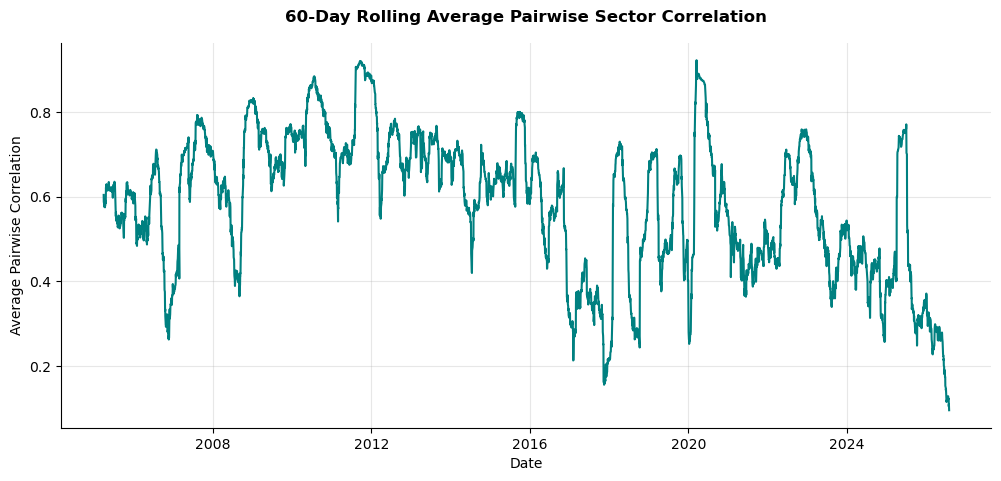

In [35]:
plt.figure(figsize=(12, 5))
plt.plot(avg_pairwise_corr.index, avg_pairwise_corr, color="teal")

plt.title("60-Day Rolling Average Pairwise Sector Correlation", fontsize=12, fontweight="bold", pad=15)
plt.xlabel("Date")
plt.ylabel("Average Pairwise Correlation")

plt.gca().spines[["top", "right"]].set_visible(False)
plt.grid(alpha=0.3)

plt.show()

In [36]:
comparison = pd.concat([avg_pairwise_corr, spy_rolling_vol], axis=1).dropna()

comparison.columns = ["Average Pairwise Correlation", "SPY Volatility"]

comparison.head()

,Average Pairwise Correlation,SPY Volatility
Date,,
2005-03-31,0.604193,0.104172
2005-04-01,0.587810,0.101517
2005-04-04,0.582772,0.100587
2005-04-05,0.576458,0.100520
2005-04-06,0.575892,0.100721


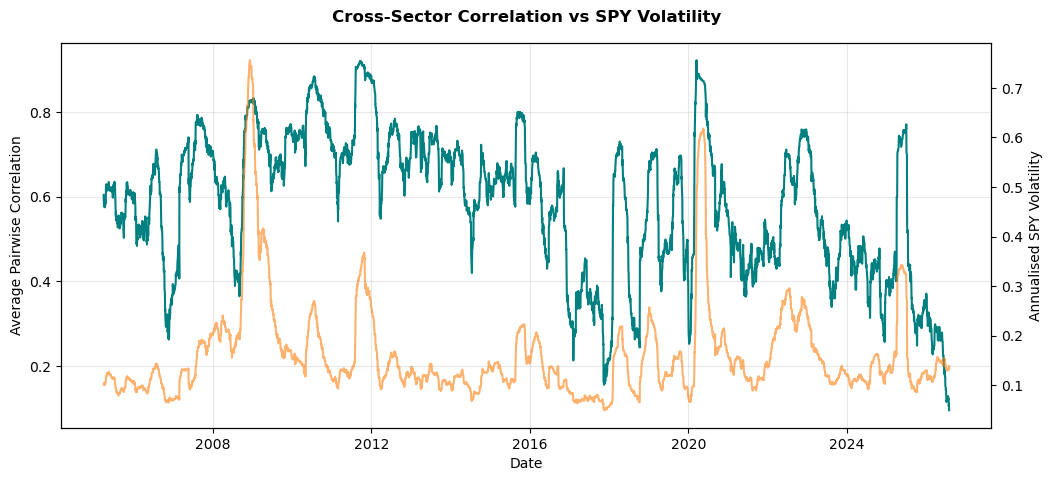

In [37]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(comparison.index, comparison["Average Pairwise Correlation"], color="teal")

ax1.set_xlabel("Date")
ax1.set_ylabel("Average Pairwise Correlation")

ax2 = ax1.twinx()

ax2.plot(comparison.index, comparison["SPY Volatility"], alpha=0.6, color="tab:orange")

ax2.set_ylabel("Annualised SPY Volatility")

plt.title("Cross-Sector Correlation vs SPY Volatility", fontsize=12, fontweight="bold", pad=15)
ax1.grid(alpha=0.3)

plt.show()

In [38]:
contemporaneous_corr = comparison["Average Pairwise Correlation"].corr(comparison["SPY Volatility"])

print(f"Correlation between sector dependence and SPY volatility: "f"{contemporaneous_corr:.3f}")

Correlation between sector dependence and SPY volatility: 0.543


## 5. Common-Factor Concentration

This section will examine whether sector returns become increasingly driven by a common market factor over time. The largest eigenvalue of each 60-day rolling correlation matrix will be calculated to measure the strength of the dominant common component. Its share of total variance will also be examined and compared with average pairwise correlation and SPY volatility.

In [39]:
largest_eigenvalue = pd.Series(index=sector_returns.index, dtype=float, name="Largest Eigenvalue")

for i in range(rolling_window - 1, len(sector_returns)):
    window_returns = sector_returns.iloc[i - rolling_window + 1 : i + 1]
    corr_matrix = window_returns.corr()
    eigenvalues = np.linalg.eigvalsh(corr_matrix)
    largest_eigenvalue.iloc[i] = eigenvalues[-1]

largest_eigenvalue = largest_eigenvalue.dropna()

In [40]:
largest_eigenvalue.describe()

count    5368.000000
mean        5.861552
std         1.181801
min         2.750400
25%         4.941278
50%         6.046487
75%         6.718932
max         8.381501
Name: Largest Eigenvalue, dtype: float64

In [41]:
print("First available date:", largest_eigenvalue.index.min().date())
print("Last available date:", largest_eigenvalue.index.max().date())

print("\nMinimum largest eigenvalue:")
print(largest_eigenvalue.idxmin().date(), largest_eigenvalue.min())

print("\nMaximum largest eigenvalue:")
print(largest_eigenvalue.idxmax().date(), largest_eigenvalue.max())

First available date: 2005-03-31
Last available date: 2026-07-31

Minimum largest eigenvalue:
2017-12-06 2.7504003738560927

Maximum largest eigenvalue:
2020-03-16 8.38150080719224


In [42]:
pc1_share = largest_eigenvalue / len(sector_tickers)

pc1_share.name = "PC1 Variance Share"

In [43]:
pc1_share.describe()

count    5368.000000
mean        0.651284
std         0.131311
min         0.305600
25%         0.549031
50%         0.671832
75%         0.746548
max         0.931278
Name: PC1 Variance Share, dtype: float64

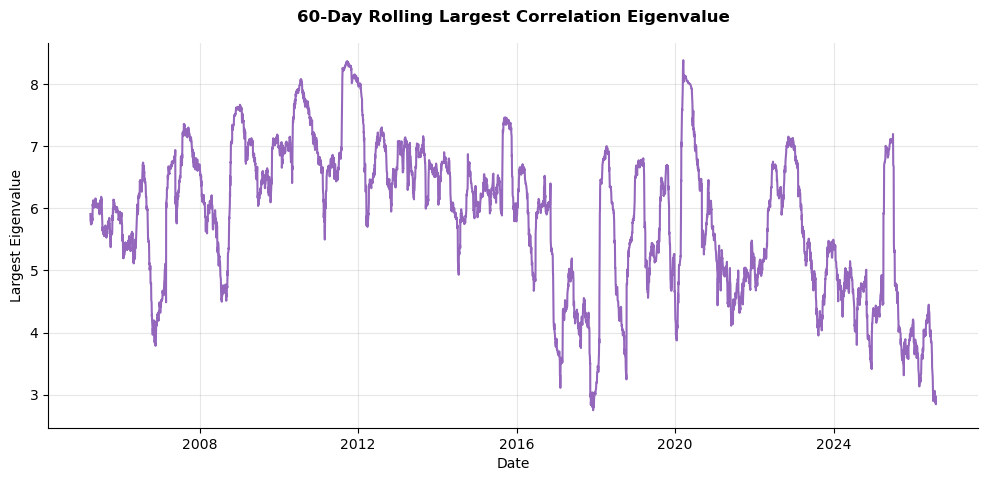

In [44]:
plt.figure(figsize=(12, 5))
plt.plot(largest_eigenvalue.index, largest_eigenvalue, color="tab:purple")

plt.title("60-Day Rolling Largest Correlation Eigenvalue", fontsize=12, fontweight="bold", pad=15)
plt.xlabel("Date")
plt.ylabel("Largest Eigenvalue")

plt.gca().spines[["top", "right"]].set_visible(False)
plt.grid(alpha=0.3)

plt.show()

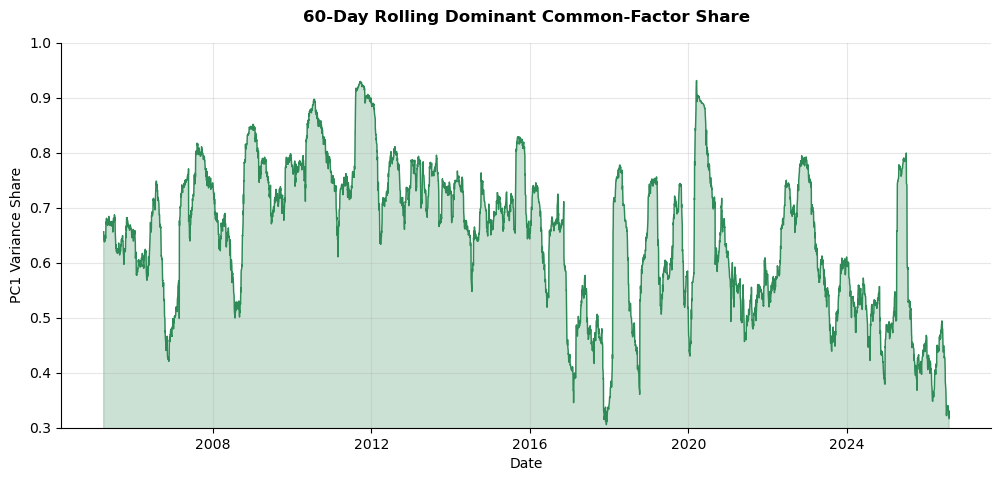

In [45]:
plt.figure(figsize=(12, 5))
plt.plot(pc1_share.index, pc1_share, linewidth=1, color="seagreen")

plt.fill_between(pc1_share.index, pc1_share, alpha=0.25, color="seagreen")

plt.title("60-Day Rolling Dominant Common-Factor Share", fontsize=12, fontweight="bold", pad=15)
plt.xlabel("Date")
plt.ylabel("PC1 Variance Share")

plt.ylim(0.3, 1)
plt.gca().spines[["top", "right"]].set_visible(False)
plt.grid(alpha=0.3)

plt.show()

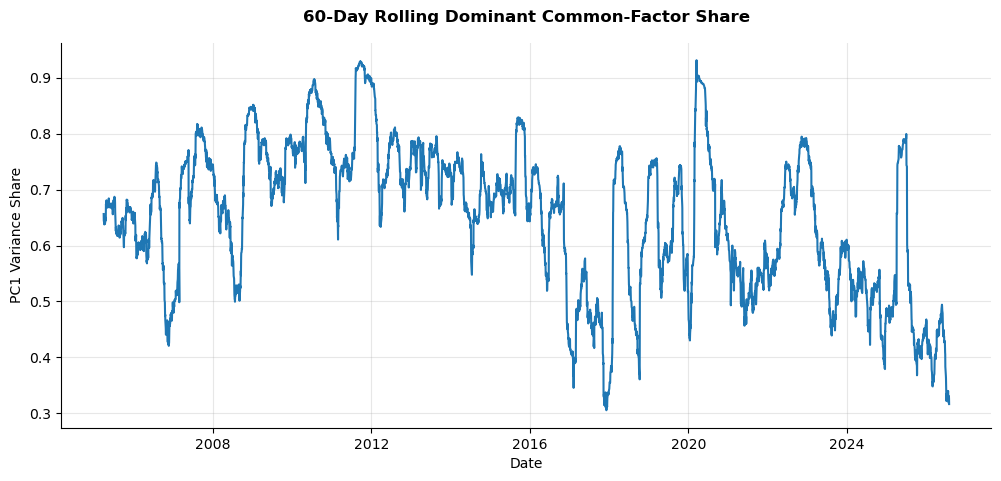

In [46]:
plt.figure(figsize=(12, 5))

plt.plot(pc1_share.index, pc1_share)

plt.title("60-Day Rolling Dominant Common-Factor Share", fontsize=12, fontweight="bold", pad=15)
plt.xlabel("Date")
plt.ylabel("PC1 Variance Share")

plt.gca().spines[["top", "right"]].set_visible(False)
plt.grid(alpha=0.3)

plt.show()

In [47]:
structure_comparison = pd.concat([avg_pairwise_corr, largest_eigenvalue, pc1_share], axis=1).dropna()

structure_comparison.head()

,Average Pairwise Correlation,Largest Eigenvalue,PC1 Variance Share
Date,,,
2005-03-31,0.604193,5.907282,0.656365
2005-04-01,0.587810,5.801986,0.644665
2005-04-04,0.582772,5.770363,0.641151
2005-04-05,0.576458,5.742803,0.638089
2005-04-06,0.575892,5.739147,0.637683


In [48]:
structure_comparison.corr()

,Average Pairwise Correlation,Largest Eigenvalue,PC1 Variance Share
Average Pairwise Correlation,1.000000,0.993452,0.993452
Largest Eigenvalue,0.993452,1.000000,1.000000
PC1 Variance Share,0.993452,1.000000,1.000000


In [49]:
eigen_vol_comparison = pd.concat([largest_eigenvalue, spy_rolling_vol], axis=1).dropna()

eigen_vol_comparison.columns = ["Largest Eigenvalue", "SPY Volatility"]

In [50]:
eigen_vol_corr = eigen_vol_comparison["Largest Eigenvalue"].corr(eigen_vol_comparison["SPY Volatility"])

print(f"Correlation between largest eigenvalue and SPY volatility: "f"{eigen_vol_corr:.3f}")

Correlation between largest eigenvalue and SPY volatility: 0.551


## 6. Forward Stress Target Construction

This section will construct a forward-looking market stress target using SPY volatility and drawdown. A stress event will be defined using elevated volatility or a significant market drawdown, and a 20-trading-day warning horizon will then be applied to identify whether stress occurs in the near future. This target will later be used to evaluate whether structural market indicators contain useful early-warning information.

In [51]:
vol_threshold = spy_rolling_vol.quantile(0.90)
drawdown_threshold = -0.10

current_stress = ((spy_rolling_vol > vol_threshold) | (spy_drawdown < drawdown_threshold)).astype(int)

In [52]:
print(f"90th percentile volatility threshold: {vol_threshold:.2%}")
print(f"Drawdown threshold: {drawdown_threshold:.2%}")

90th percentile volatility threshold: 25.72%
Drawdown threshold: -10.00%


In [53]:
current_stress.value_counts()

SPY
0    4046
1    1381
Name: count, dtype: int64

In [54]:
current_stress.value_counts(normalize=True)

SPY
0    0.745532
1    0.254468
Name: proportion, dtype: float64

In [55]:
warning_horizon = 20
future_stress = pd.Series(0, index=current_stress.index, dtype=int, name="Future Stress")

for i in range(len(current_stress) - warning_horizon):
    future_window = current_stress.iloc[i + 1 : i + 1 + warning_horizon]
    future_stress.iloc[i] = int(future_window.max() == 1)

In [56]:
future_stress = future_stress.iloc[:-warning_horizon]

In [57]:
future_stress.value_counts()

Future Stress
0    3701
1    1706
Name: count, dtype: int64

In [58]:
future_stress.value_counts(normalize=True)

Future Stress
0    0.684483
1    0.315517
Name: proportion, dtype: float64

In [59]:
print("First target date:", future_stress.index.min().date())
print("Last target date:", future_stress.index.max().date())

First target date: 2005-01-04
Last target date: 2026-07-02


In [60]:
model_data = pd.concat([avg_pairwise_corr, largest_eigenvalue, spy_rolling_vol, future_stress], axis=1).dropna()

In [61]:
model_data["Future Stress"] = model_data["Future Stress"].astype(int)

In [62]:
model_data.columns = ["Average Pairwise Correlation", "Largest Eigenvalue", "SPY Volatility", "Future Stress"]

model_data

,Average Pairwise Correlation,Largest Eigenvalue,SPY Volatility,Future Stress
Date,,,,
2005-03-31,0.604193,5.907282,0.104172,0
2005-04-01,0.587810,5.801986,0.101517,0
2005-04-04,0.582772,5.770363,0.100587,0
2005-04-05,0.576458,5.742803,0.100520,0
2005-04-06,0.575892,5.739147,0.100721,0
...,...,...,...,...
2026-06-26,0.153290,3.450883,0.136926,0
2026-06-29,0.149674,3.373448,0.139629,0
2026-06-30,0.148694,3.351242,0.140085,0


In [63]:
model_data["Future Stress"].value_counts()

Future Stress
0    3642
1    1706
Name: count, dtype: int64

In [64]:
model_data["Future Stress"].value_counts(normalize=True)

Future Stress
0    0.681002
1    0.318998
Name: proportion, dtype: float64

## 7. Early-Warning Signal Analysis

This section will examine whether changes in cross-sector dependence and common-factor concentration contain information about future market stress. The structural indicators will be compared across future stress and non-stress periods to assess whether they show meaningful differences before stress events.

In [65]:
signal_comparison = model_data.groupby("Future Stress")[["Average Pairwise Correlation", "Largest Eigenvalue", "SPY Volatility"]].mean()

signal_comparison

,Average Pairwise Correlation,Largest Eigenvalue,SPY Volatility
Future Stress,,,
0,0.539212,5.536840,0.122898
1,0.686514,6.588629,0.246494


In [66]:
median_comparison = model_data.groupby("Future Stress")[["Average Pairwise Correlation", "Largest Eigenvalue", "SPY Volatility"]].median()

median_comparison

,Average Pairwise Correlation,Largest Eigenvalue,SPY Volatility
Future Stress,,,
0,0.553791,5.678726,0.117512
1,0.705760,6.701169,0.209614


In [67]:
stress_difference = (signal_comparison.loc[1] - signal_comparison.loc[0])

stress_difference

Average Pairwise Correlation    0.147302
Largest Eigenvalue              1.051790
SPY Volatility                  0.123596
dtype: float64

In [68]:
relative_difference = ((signal_comparison.loc[1] / signal_comparison.loc[0]) - 1) * 100

relative_difference

Average Pairwise Correlation     27.317965
Largest Eigenvalue               18.996208
SPY Volatility                  100.568005
dtype: float64

In [69]:
model_data["Correlation Quintile"] = pd.qcut(model_data["Average Pairwise Correlation"], q=5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"])

In [70]:
stress_probability = model_data.groupby("Correlation Quintile", observed=True)["Future Stress"].mean()

stress_probability

Correlation Quintile
Q1    0.100000
Q2    0.175865
Q3    0.301869
Q4    0.320861
Q5    0.696262
Name: Future Stress, dtype: float64

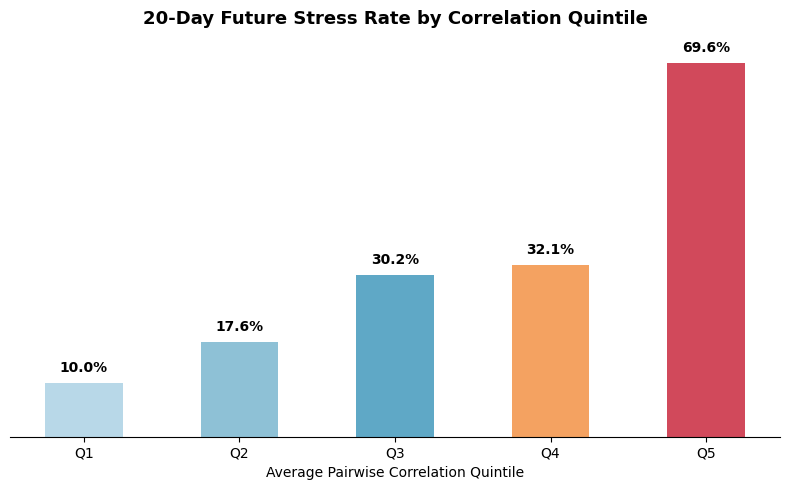

In [71]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(stress_probability.index, stress_probability.values, width=0.50, color=["#B8D8E8", "#8EC1D6", "#5FA8C6", "#F4A261", "#D1495B"])

for bar, value in zip(bars, stress_probability.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.015,
        f"{value:.1%}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title("20-Day Future Stress Rate by Correlation Quintile", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Average Pairwise Correlation Quintile")
#ax.set_ylabel("Future Stress Rate")

ax.spines[["top", "right", "left"]].set_visible(False)
ax.set_axisbelow(True)
ax.set_yticks([])

plt.tight_layout()
plt.show()

## 8. Incremental Predictive Analysis

This section will test whether cross-sector dependence provides predictive information about future market stress beyond contemporaneous market volatility. A volatility-only baseline model will be compared with a second model that also includes average pairwise sector correlation. Both models will be evaluated on a chronologically held-out test period using ROC-AUC.

In [72]:
split_index = int(len(model_data) * 0.80)
purge_gap = warning_horizon

train_data = model_data.iloc[:split_index - purge_gap].copy()
test_data = model_data.iloc[split_index:].copy()

print("Training period:")
print(train_data.index.min().date(), "to", train_data.index.max().date())

print("\nTesting period:")
print(test_data.index.min().date(), "to", test_data.index.max().date())

print("\nTraining observations:", len(train_data))
print("Testing observations:", len(test_data))

print("\nPurged observations:", purge_gap)

Training period:
2005-03-31 to 2022-02-25

Testing period:
2022-03-28 to 2026-07-02

Training observations: 4258
Testing observations: 1070

Purged observations: 20


In [73]:
y_train = train_data["Future Stress"]
y_test = test_data["Future Stress"]

In [74]:
X_train_vol = train_data[["SPY Volatility"]]
X_test_vol = test_data[["SPY Volatility"]]

scaler_vol = StandardScaler()

X_train_vol_scaled = scaler_vol.fit_transform(X_train_vol)
X_test_vol_scaled = scaler_vol.transform(X_test_vol)

model_vol = LogisticRegression()
model_vol.fit(X_train_vol_scaled, y_train)

prob_vol = model_vol.predict_proba(X_test_vol_scaled)[:, 1]

auc_vol = roc_auc_score(y_test, prob_vol)

print(f"Volatility-only ROC-AUC: {auc_vol:.3f}")

Volatility-only ROC-AUC: 0.948


In [75]:
X_train_struct = train_data[["SPY Volatility", "Average Pairwise Correlation"]]
X_test_struct = test_data[["SPY Volatility", "Average Pairwise Correlation"]]

scaler_struct = StandardScaler()

X_train_struct_scaled = scaler_struct.fit_transform(X_train_struct)
X_test_struct_scaled = scaler_struct.transform(X_test_struct)

model_struct = LogisticRegression()
model_struct.fit(X_train_struct_scaled, y_train)

prob_struct = model_struct.predict_proba(X_test_struct_scaled)[:, 1]

auc_struct = roc_auc_score(y_test, prob_struct)

print(f"Volatility + Correlation ROC-AUC: {auc_struct:.3f}")

Volatility + Correlation ROC-AUC: 0.954


In [76]:
print(f"Baseline ROC-AUC: {auc_vol:.3f}")
print(f"Structural ROC-AUC: {auc_struct:.3f}")
print(f"AUC improvement: {auc_struct - auc_vol:.3f}")

Baseline ROC-AUC: 0.948
Structural ROC-AUC: 0.954
AUC improvement: 0.006


## 9. Lead–Lag Analysis

This section will examine whether changes in cross-sector dependence precede changes in market volatility. Structural indicators will be shifted across different lead horizons and compared with subsequent SPY volatility to evaluate their potential as early-warning signals.

In [77]:
lead_horizons = [0, 5, 10, 20, 40, 60]
lead_lag_results = []

for horizon in lead_horizons:
    future_vol = spy_rolling_vol.shift(-horizon)
    comparison = pd.concat([avg_pairwise_corr, future_vol], axis=1).dropna()
    
    comparison.columns = ["Average Pairwise Correlation", "Future SPY Volatility"]
    corr = comparison["Average Pairwise Correlation"].corr(comparison["Future SPY Volatility"])
    lead_lag_results.append({"Lead (Trading Days)": horizon, "Correlation": corr})

lead_lag_results = pd.DataFrame(lead_lag_results)

lead_lag_results

,Lead (Trading Days),Correlation
0,0,0.542693
1,5,0.531957
2,10,0.512031
3,20,0.451716
4,40,0.284077
5,60,0.105690


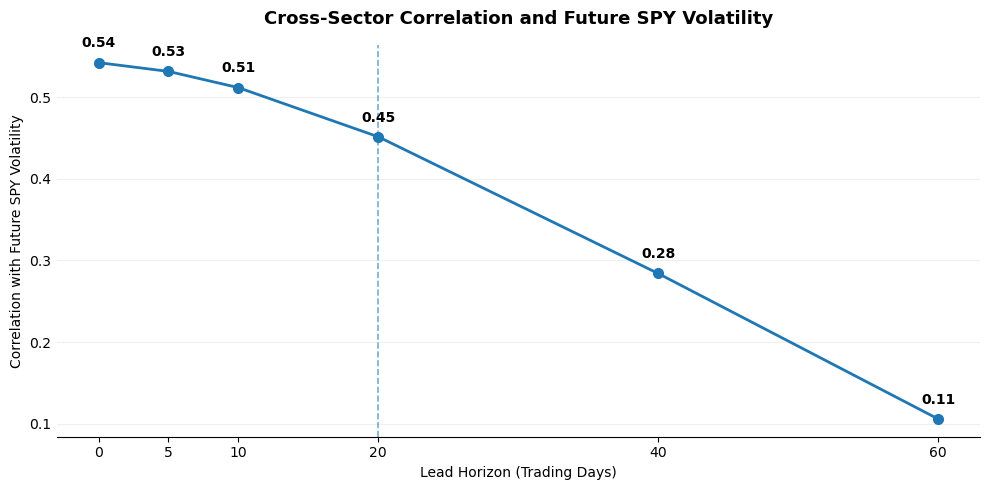

In [78]:
fig, ax = plt.subplots(figsize=(10, 5))
x = lead_lag_results["Lead (Trading Days)"]
y = lead_lag_results["Correlation"]

ax.plot(x, y, linewidth=2, marker="o", markersize=7)
ax.axvline(20, linestyle="--", linewidth=1.2, alpha=0.6)

for xi, yi in zip(x, y):
    ax.text(xi, yi + 0.015,f"{yi:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("Cross-Sector Correlation and Future SPY Volatility", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Lead Horizon (Trading Days)")
ax.set_ylabel("Correlation with Future SPY Volatility")

ax.set_xticks(x)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)

ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Interpretation

Average pairwise sector correlation shows a strong positive association with contemporaneous and near-term SPY volatility. The relationship remains relatively strong at 5- and 10-trading-day leads, before declining to approximately 0.45 at 20 days and weakening substantially at longer horizons. This suggests that elevated cross-sector dependence may contain near-term information about subsequent market volatility, although the analysis provides lead-lag evidence rather than proof of independent predictive causality.

## 10. Expanding-Window Out-of-Sample Evaluation

This section evaluates whether the predictive contribution of cross-sector dependence is stable across different out-of-sample periods. An expanding-window approach is used so that each test period is predicted using only information available beforehand.

In [79]:
initial_train_size = int(len(model_data) * 0.60)
test_block_size = 250

expanding_results = []
start = initial_train_size

while start + test_block_size <= len(model_data):
    train = model_data.iloc[:start].copy()
    test = model_data.iloc[start:start + test_block_size].copy()
    y_train = train["Future Stress"]
    y_test = test["Future Stress"]

    # Skip blocks with only one target class
    if y_test.nunique() < 2:
        start += test_block_size
        continue

    # Baseline model: volatility only
    X_train_vol = train[["SPY Volatility"]]
    X_test_vol = test[["SPY Volatility"]]

    scaler_vol = StandardScaler()
    X_train_vol_scaled = scaler_vol.fit_transform(X_train_vol)
    X_test_vol_scaled = scaler_vol.transform(X_test_vol)

    model_vol = LogisticRegression()
    model_vol.fit(X_train_vol_scaled, y_train)

    prob_vol = model_vol.predict_proba(X_test_vol_scaled)[:, 1]
    auc_vol = roc_auc_score(y_test, prob_vol)

    # Structural model: volatility + correlation
    X_train_struct = train[
        ["SPY Volatility", "Average Pairwise Correlation"]
    ]

    X_test_struct = test[
        ["SPY Volatility", "Average Pairwise Correlation"]
    ]

    scaler_struct = StandardScaler()
    X_train_struct_scaled = scaler_struct.fit_transform(X_train_struct)
    X_test_struct_scaled = scaler_struct.transform(X_test_struct)

    model_struct = LogisticRegression()
    model_struct.fit(X_train_struct_scaled, y_train)

    prob_struct = model_struct.predict_proba(
        X_test_struct_scaled
    )[:, 1]

    auc_struct = roc_auc_score(y_test, prob_struct)

    expanding_results.append({
        "Test Start": test.index.min(),
        "Test End": test.index.max(),
        "Baseline AUC": auc_vol,
        "Structural AUC": auc_struct,
        "AUC Improvement": auc_struct - auc_vol
    })

    start += test_block_size

expanding_results = pd.DataFrame(expanding_results)

expanding_results

,Test Start,Test End,Baseline AUC,Structural AUC,AUC Improvement
0,2017-12-26,2018-12-21,0.517263,0.513640,-0.003623
1,2018-12-24,2019-12-19,0.987234,0.988085,0.000851
2,2019-12-20,2020-12-16,0.825134,0.826236,0.001102
3,2021-12-15,2022-12-12,0.959224,0.964670,0.005446
4,2022-12-13,2023-12-11,0.908873,0.908873,0.000000
5,2024-12-10,2025-12-09,0.970529,0.969522,-0.001007


In [80]:
expanding_results[["Baseline AUC", "Structural AUC", "AUC Improvement"]].describe()

,Baseline AUC,Structural AUC,AUC Improvement
count,6.000000,6.000000,6.000000
mean,0.861376,0.861838,0.000461
std,0.178500,0.180461,0.002982
min,0.517263,0.513640,-0.003623
25%,0.846069,0.846895,-0.000755
50%,0.934048,0.936771,0.000426
75%,0.967703,0.968309,0.001039
max,0.987234,0.988085,0.005446


In [81]:
improvement_rate = (expanding_results["AUC Improvement"] > 0).mean()

print(f"Share of test blocks with structural improvement: "f"{improvement_rate:.2%}")

Share of test blocks with structural improvement: 50.00%


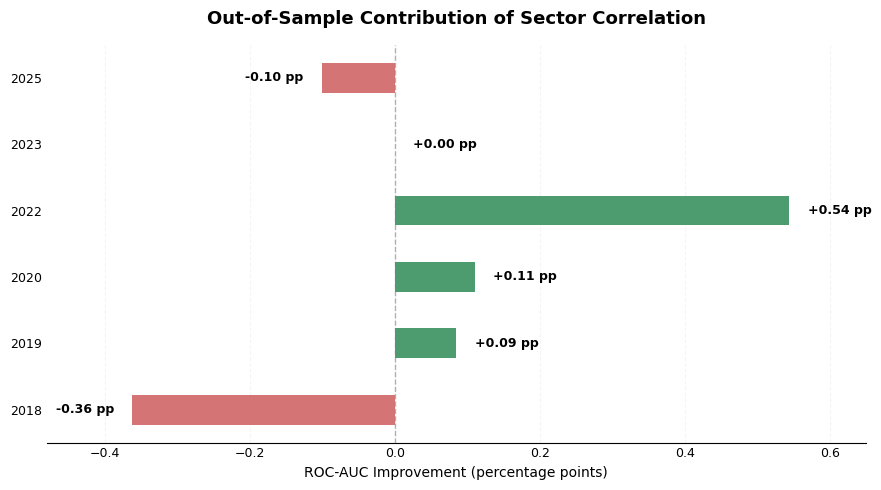

In [82]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_data = expanding_results.copy()

plot_data["Test Period"] = plot_data["Test End"].dt.year.astype(str)
plot_data["AUC Improvement pp"] = plot_data["AUC Improvement"] * 100

colors = ["seagreen" if value > 0 else "indianred" for value in plot_data["AUC Improvement pp"]]
bars = ax.barh(plot_data["Test Period"], plot_data["AUC Improvement pp"], color=colors, alpha=0.85, height=0.45)

ax.axvline(0, color="grey", linewidth=1, linestyle="--", alpha=0.6)

for bar, value in zip(bars, plot_data["AUC Improvement pp"]):
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    ax.text(
        x + (0.025 if value >= 0 else -0.025),
        y,
        f"{value:+.2f} pp",
        va="center",
        ha="left" if value >= 0 else "right",
        fontsize=9,
        fontweight="bold"
    )

ax.set_title("Out-of-Sample Contribution of Sector Correlation", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("ROC-AUC Improvement (percentage points)", fontsize=10)
ax.set_ylabel("")

ax.set_xlim(-0.48, 0.65)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="both", length=0, labelsize=9)
ax.grid(axis="x", alpha=0.12, linestyle="--")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Interpretation

The expanding-window evaluation shows that adding average pairwise sector correlation provides only a small and time-varying improvement over the volatility-only benchmark.

Across the out-of-sample periods, the mean ROC-AUC increased from approximately 0.8614 to 0.8618. The structural model improved performance in some periods, particularly around 2022–2023, but produced little or negative incremental improvement in others.

These results suggest that cross-sector dependence contains information associated with future market stress, but much of this information overlaps with that already captured by market volatility. Therefore, sector correlation appears more useful as a complementary early-warning indicator than as a consistently independent source of predictive improvement.

## 11. Crisis and Market-Stress Validation

This section will examine how cross-sector dependence behaves around major periods of financial market stress. Historical stress episodes will be used to assess whether average pairwise correlation rises during broad market disruptions and whether changes are already visible before each event.

In [83]:
stress_events = {
    "Global Financial Crisis": ("2008-09-01", "2009-03-31"),
    "COVID-19": ("2020-02-01", "2020-05-31"),
    "2022 Market Stress": ("2022-01-01", "2022-10-31")
}

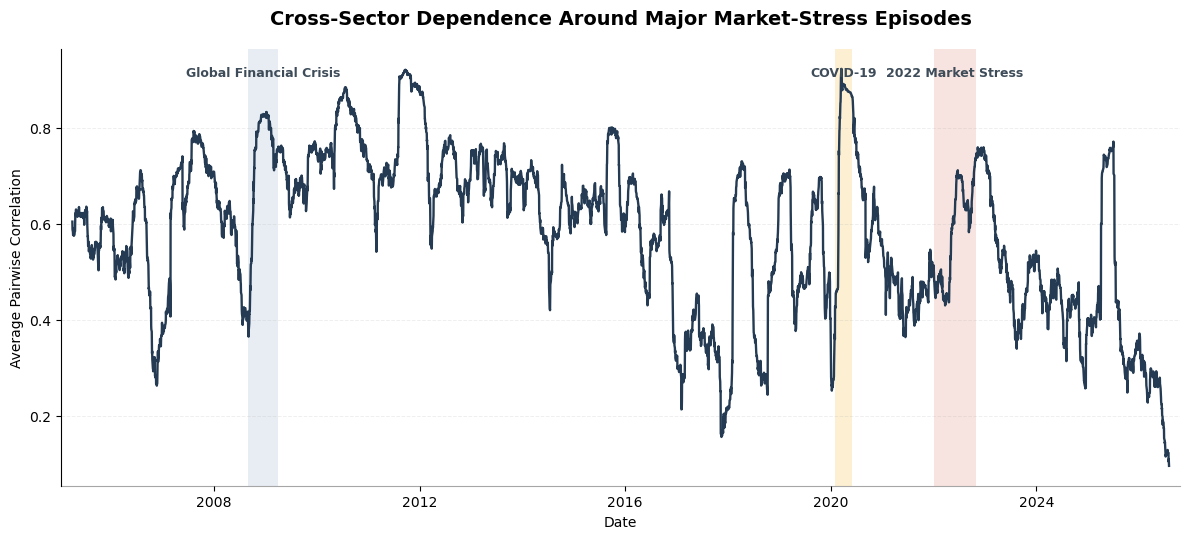

In [84]:
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(avg_pairwise_corr.index, avg_pairwise_corr, color="#243B53", linewidth=1.7, label="Average Pairwise Correlation", zorder=3)

event_styles = {
    "Global Financial Crisis": {"color": "#D9E2EC", "alpha": 0.60},
    "COVID-19": {"color": "#F6C85F", "alpha": 0.28},
    "2022 Market Stress": {"color": "#D97B66", "alpha": 0.20}
}

for event, (start, end) in stress_events.items():
    start = pd.Timestamp(start)
    end = pd.Timestamp(end)
    ax.axvspan(
        start,
        end,
        color=event_styles[event]["color"],
        alpha=event_styles[event]["alpha"],
        linewidth=0,
        zorder=1
    )
    midpoint = start + (end - start) / 2
    ax.text(
        midpoint,
        0.96,
        event,
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="top",
        fontsize=9,
        fontweight="bold",
        color="#3E4C59"
    )

ax.set_title("Cross-Sector Dependence Around Major Market-Stress Episodes", fontsize=14, fontweight="bold", pad=18)
ax.set_xlabel("Date", fontsize=10)
ax.set_ylabel("Average Pairwise Correlation", fontsize=10)


ax.grid( axis="y", linestyle="--", linewidth=0.7, alpha=0.20)
ax.grid(axis="x", visible=False)

ax.spines[["top", "right"]].set_visible(False)
ax.spines["bottom"].set_alpha(0.35)
ax.margins(x=0.01)

plt.tight_layout()
plt.show()

In [85]:
event_results = []
overall_mean_corr = avg_pairwise_corr.mean()

for event, (start, end) in stress_events.items():
    event_corr = avg_pairwise_corr.loc[start:end]
    
    event_results.append({
        "Event": event,
        "Mean Correlation": event_corr.mean(),
        "Maximum Correlation": event_corr.max(),
        "Overall Mean": overall_mean_corr,
        "Difference from Overall Mean":
            event_corr.mean() - overall_mean_corr
    })

event_results = pd.DataFrame(event_results)
event_results

,Event,Mean Correlation,Maximum Correlation,Overall Mean,Difference from Overall Mean
0,Global Financial Crisis,0.733373,0.832437,0.584456,0.148917
1,COVID-19,0.791408,0.922131,0.584456,0.206952
2,2022 Market Stress,0.580109,0.740169,0.584456,-0.004347


In [86]:
pre_event_results = []

for event, (start, end) in stress_events.items():
    start_date = pd.Timestamp(start)
    end_date = pd.Timestamp(end)
    event_corr = avg_pairwise_corr.loc[start_date:end_date]
    previous_data = avg_pairwise_corr.loc[avg_pairwise_corr.index < start_date].tail(60)
    
    pre_event_results.append({
        "Event": event,
        "Pre-Event Mean": previous_data.mean(),
        "Event Mean": event_corr.mean(),
        "Change":
            event_corr.mean() - previous_data.mean()
    })

pre_event_results = pd.DataFrame(pre_event_results)
pre_event_results

,Event,Pre-Event Mean,Event Mean,Change
0,Global Financial Crisis,0.456534,0.733373,0.276839
1,COVID-19,0.408779,0.791408,0.382630
2,2022 Market Stress,0.484357,0.580109,0.095751


### Interpretation

Cross-sector dependence increased substantially during the Global Financial Crisis and the COVID-19 shock. Average pairwise correlation rose from approximately 0.46 before the Global Financial Crisis to 0.73 during the event, and from approximately 0.41 before the COVID-19 shock to 0.79 during the event. The COVID-19 period also recorded the highest maximum correlation, above 0.92, indicating exceptionally strong market-wide co-movement.

The 2022 market-stress period produced a smaller increase, from approximately 0.48 before the event to 0.58 during the event, suggesting that the degree of cross-sector synchronization varies across stress episodes.

Overall, the results show that cross-sector dependence is particularly sensitive to severe system-wide market disruptions. The pre-event analysis also supports its potential usefulness as a structural early-warning indicator when considered alongside the forward-looking and lead-lag evidence presented earlier.

## 12. Composite Early-Warning Indicator

This section will combine market volatility and cross-sector dependence into a transparent composite early-warning score. The indicator will summarise both conventional market risk and changes in market structure, and will then be translated into interpretable warning levels ranging from Low to Severe.

In [87]:
warning_data = pd.concat([avg_pairwise_corr, spy_rolling_vol], axis=1).dropna()

warning_data.columns = ["Average Pairwise Correlation", "SPY Volatility"]

warning_data["Correlation Z"] = (warning_data["Average Pairwise Correlation"] - warning_data["Average Pairwise Correlation"].mean()
                                )/ warning_data["Average Pairwise Correlation"].std()

warning_data["Volatility Z"] = (warning_data["SPY Volatility"] - warning_data["SPY Volatility"].mean()
                               ) / warning_data["SPY Volatility"].std()

In [88]:
warning_data["Composite Score"] = (warning_data["Correlation Z"] + warning_data["Volatility Z"]) / 2

In [89]:
warning_data["Composite Score"].describe()

count    5.368000e+03
mean     1.058931e-16
std      8.782633e-01
min     -1.853427e+00
25%     -5.723982e-01
50%     -5.116885e-02
75%      4.195689e-01
max      3.693089e+00
Name: Composite Score, dtype: float64

In [90]:
print("Minimum composite score:")
print(warning_data["Composite Score"].idxmin().date(), warning_data["Composite Score"].min())

print("\nMaximum composite score:")
print(warning_data["Composite Score"].idxmax().date(), warning_data["Composite Score"].max())

Minimum composite score:
2017-11-15 -1.8534270982844636

Maximum composite score:
2008-12-08 3.6930889402188063


In [91]:
low_threshold = warning_data["Composite Score"].quantile(0.50)
elevated_threshold = warning_data["Composite Score"].quantile(0.75)
high_threshold = warning_data["Composite Score"].quantile(0.90)

In [92]:
def classify_warning(score):
    if score < low_threshold:
        return "Low"
    elif score < elevated_threshold:
        return "Elevated"
    elif score < high_threshold:
        return "High"
    else:
        return "Severe"

warning_data["Warning Level"] = warning_data["Composite Score"].apply(classify_warning)

In [93]:
warning_data["Warning Level"].value_counts()

Warning Level
Low         2684
Elevated    1342
High         805
Severe       537
Name: count, dtype: int64

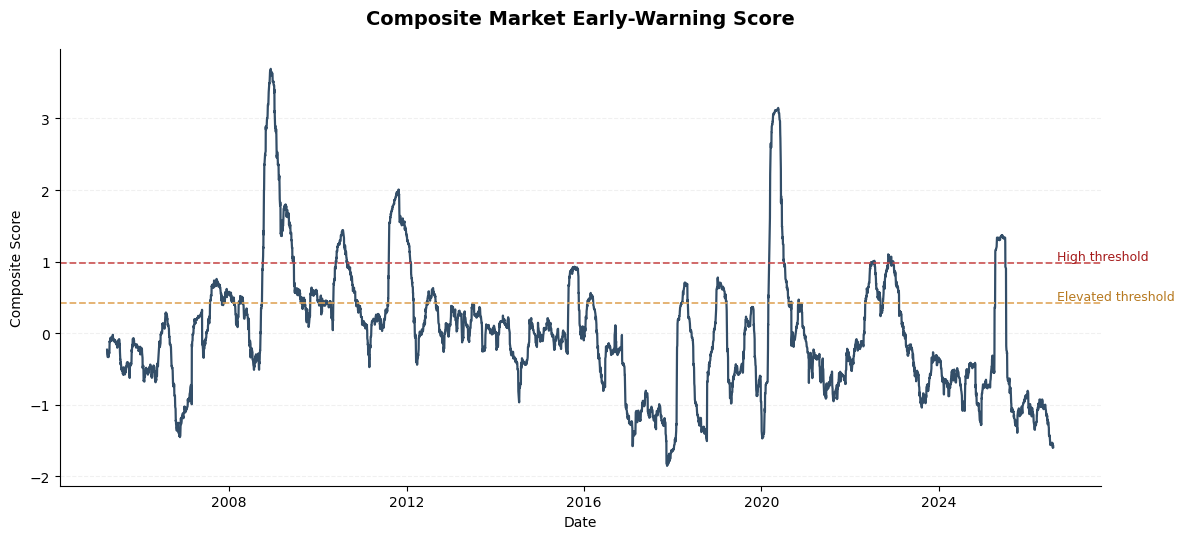

In [94]:
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(warning_data.index, warning_data["Composite Score"], color="#334E68", linewidth=1.6)

ax.axhline(elevated_threshold, color="#E0A458", linestyle="--", linewidth=1.3, alpha=0.9)
ax.axhline(high_threshold, color="#C94C4C", linestyle="--", linewidth=1.3, alpha=0.9)


ax.text(warning_data.index[-1], elevated_threshold, " Elevated threshold", color="#B7791F", fontsize=9, va="bottom")
ax.text(warning_data.index[-1], high_threshold, " High threshold", color="#A61B1B", fontsize=9, va="bottom")

ax.set_title("Composite Market Early-Warning Score", fontsize=14, fontweight="bold", pad=18)
ax.set_xlabel("Date")
ax.set_ylabel("Composite Score")

ax.grid(axis="y", linestyle="--", alpha=0.18)
ax.grid(axis="x", visible=False)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [95]:
warning_evaluation = pd.concat([warning_data["Warning Level"], future_stress], axis=1).dropna()

warning_stress_probability = warning_evaluation.groupby("Warning Level")["Future Stress"].mean()

warning_stress_probability

Warning Level
Elevated    0.298063
High        0.591304
Low         0.116742
Severe      0.966480
Name: Future Stress, dtype: float64

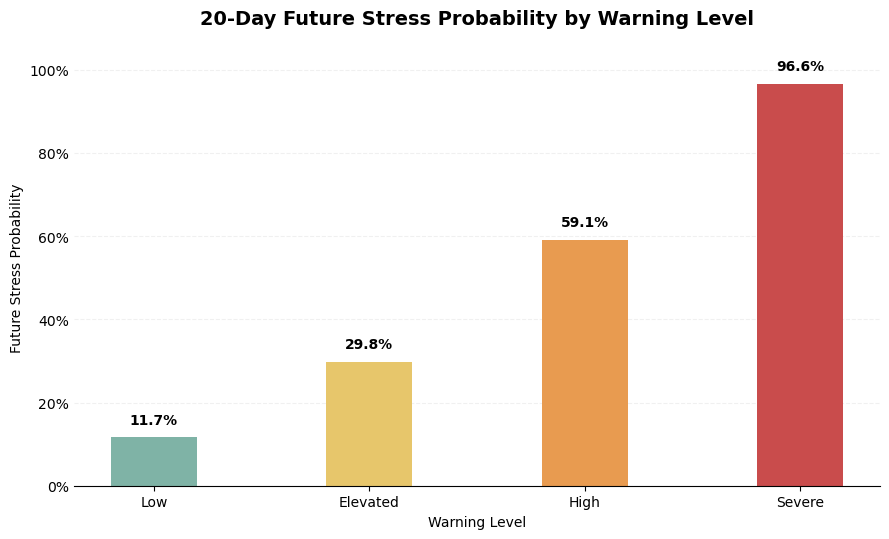

In [96]:
warning_stress_probability = warning_stress_probability.reindex(["Low", "Elevated", "High", "Severe"])

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = ["#7FB3A6", "#E7C66B", "#E89B50", "#C94C4C"]
bars = ax.bar(warning_stress_probability.index, warning_stress_probability.values, color=colors, width=0.40)

for bar, value in zip(bars, warning_stress_probability.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.025,
        f"{value:.1%}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title("20-Day Future Stress Probability by Warning Level", fontsize=14, fontweight="bold", pad=18)
ax.set_xlabel("Warning Level")
ax.set_ylabel("Future Stress Probability")

ax.set_ylim(0, 1.05)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.grid(axis="y", linestyle="--", alpha=0.18)
ax.set_axisbelow(True)

ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)

plt.tight_layout()
plt.show()

## 13. Final Evaluation and Research Findings

This section consolidates the main empirical results and evaluates whether changes in cross-sector market dependence provide useful early-warning information about future financial stress.

The evaluation considers the relationship between sector correlation and future volatility, performance during major historical stress episodes, incremental predictive value beyond volatility, and the effectiveness of the composite early-warning indicator.

In [97]:
final_results = pd.DataFrame({
    "Metric": [
        "Future Stress Probability - Lowest Correlation Quintile",
        "Future Stress Probability - Highest Correlation Quintile",
        "Volatility-Only ROC-AUC",
        "Volatility + Correlation ROC-AUC",
        "Incremental ROC-AUC",
        "Mean Walk-Forward AUC Improvement",
        "Low Warning - Future Stress Probability",
        "Severe Warning - Future Stress Probability"
    ],
    "Result": [
        stress_probability.loc["Q1"],
        stress_probability.loc["Q5"],
        auc_vol,
        auc_struct,
        auc_struct - auc_vol,
        expanding_results["AUC Improvement"].mean(),
        warning_stress_probability.loc["Low"],
        warning_stress_probability.loc["Severe"]
    ]
})

final_results

,Metric,Result
0,Future Stress Probability - Lowest Correlation...,0.100000
1,Future Stress Probability - Highest Correlatio...,0.696262
2,Volatility-Only ROC-AUC,0.970529
3,Volatility + Correlation ROC-AUC,0.969522
4,Incremental ROC-AUC,-0.001007
5,Mean Walk-Forward AUC Improvement,0.000461
6,Low Warning - Future Stress Probability,0.116742
7,Severe Warning - Future Stress Probability,0.966480


### 13.1 Key Research Findings

The results provide evidence that changes in cross-sector dependence are associated with future market stress, although their incremental predictive contribution beyond volatility is limited and varies over time.

- **Higher cross-sector correlation is associated with greater future stress.** Future stress probability increased from approximately 10.0% in the lowest correlation quintile to 69.6% in the highest quintile.

- **Cross-sector dependence contains forward-looking information.** Correlation remained positively associated with future SPY volatility across several forecasting horizons, although the relationship weakened as the horizon increased.

- **Major historical stress episodes were accompanied by increased market dependence.** Cross-sector correlation rose substantially during the Global Financial Crisis and COVID-19 shock, while the increase during the 2022 market-stress period was more moderate.

- **Incremental predictive improvement beyond volatility was limited and time-varying.** Adding sector correlation produced only small changes in ROC-AUC relative to the volatility-only model, with both positive and negative improvements across walk-forward periods.

- **The composite warning indicator effectively differentiated risk states.** Future stress probability increased from approximately 11.7% during Low warning periods to 96.6% during Severe warning periods. Because the indicator incorporates both volatility and structural information, this result should be interpreted as evidence of effective risk-state classification rather than independent predictive power from correlation alone.

Overall, cross-sector correlation appears most useful as a **complementary market-structure indicator** alongside conventional volatility measures rather than as a standalone replacement.


### 13.2 Limitations

Several limitations should be considered when interpreting the results:

- The analysis uses sector ETFs as proxies for broad market structure, so the results may differ for individual equities, international markets, or other asset classes.

- Stress is defined using SPY volatility and drawdown thresholds. Alternative definitions of market stress could produce different classifications.

- Rolling correlation and eigenvalue measures depend on the selected estimation window and may respond differently under alternative window lengths.

- The predictive models are intentionally simple and designed to test incremental information rather than maximise forecasting performance.

- Walk-forward results show that the additional predictive value of sector correlation is not stable across all market periods.

- The composite warning score combines volatility and structural indicators, so its strong separation of warning levels should not be interpreted as evidence that correlation alone predicts future stress.

### 13.3 Final Conclusion

This study investigated whether changes in cross-sector market dependence provide early-warning information about future financial stress beyond conventional volatility measures.

The results show that periods of elevated cross-sector correlation are associated with substantially higher probabilities of future market stress. Major historical disruptions, particularly the Global Financial Crisis and COVID-19 shock, were also accompanied by pronounced increases in market-wide dependence.

However, the incremental forecasting benefit of adding sector correlation to a volatility-based model was small and inconsistent across walk-forward periods. Therefore, the evidence does not support replacing conventional volatility measures with correlation-based indicators.

Instead, cross-sector dependence appears most valuable as a **complementary measure of market structure**. When considered alongside volatility, it can provide a broader view of systemic conditions by identifying periods in which diversification weakens and markets become increasingly synchronized.

Overall, the original hypothesis receives **partial support**: cross-sector market structure contains meaningful forward-looking information about financial stress, but its incremental predictive value beyond volatility is modest and time-varying.